# Phase 1 — Baseline MLP for Chest X-Ray Classification

**Learning Goals**
- Build and train an MLP using the Keras Sequential API
- Compare activation functions (ReLU, LeakyReLU, ELU)
- Compare optimizers (SGD, Adam, RMSprop, Nadam)
- Implement a learning-rate schedule

**Tasks to complete:**
1. `TODO 1` in `src/data_loader.py` — `get_data_generators()`
2. `TODO 3` in `src/data_loader.py` — `compute_class_weights()`
3. `TODO 4` in `src/models.py` — `build_baseline_mlp()`
4. `TODO 9` in `src/train.py` — `get_callbacks()`
5. `TODO 10` in `src/train.py` — `get_lr_schedule()`
6. `TODO 11` in `src/train.py` — `train_model()`

Run `pytest tests/test_phase1.py -v` to check your work.

In [15]:
# Standard imports — do not modify
import sys
sys.path.insert(0, '..')   # makes src/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1. Dataset Setup

Download the dataset from Kaggle first:
```bash
kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
unzip chest-xray-pneumonia.zip -d ../data/
```
After unzipping, the structure should be:
```
data/chest_xray/train/NORMAL/
data/chest_xray/train/PNEUMONIA/
data/chest_xray/val/
data/chest_xray/test/
```

In [16]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nagasantoshch","key":"8c938ab2596757413d2f7a895a4bb707"}'}

In [18]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [19]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:21<00:00, 116MB/s]



In [20]:
!unzip chest-xray-pneumonia.zip -d data/

Streaming output truncated to the last 5000 lines.
  inflating: data/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0446-0001.j

In [21]:
!ls data/chest_xray

chest_xray  __MACOSX  test  train  val


In [22]:
!rm -rf data/chest_xray/__MACOSX

In [23]:
!rm -rf data/chest_xray/chest_xray

In [24]:
from src.data_loader import describe_dataset, get_data_generators, compute_class_weights

# Inspect dataset structure
# summary = describe_dataset('../data/chest_xray')
summary = describe_dataset('data/chest_xray')
for split, counts in summary.items():
    print(f'{split}: {counts}')

train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
val: {'NORMAL': 8, 'PNEUMONIA': 8}
test: {'NORMAL': 234, 'PNEUMONIA': 390}


In [25]:
# TODO: implement get_data_generators() in src/data_loader.py, then run this cell
train_gen, val_gen, test_gen = get_data_generators(
    # data_dir='../data/chest_xray',
    data_dir='data/chest_xray',
    img_size=(64, 64),    # use 64x64 for faster MLP training
    batch_size=32,
    augment_train=True,
)
print('Train batches:', len(train_gen))
print('Val   batches:', len(val_gen))
print('Test  batches:', len(test_gen))

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train batches: 163
Val   batches: 1
Test  batches: 20


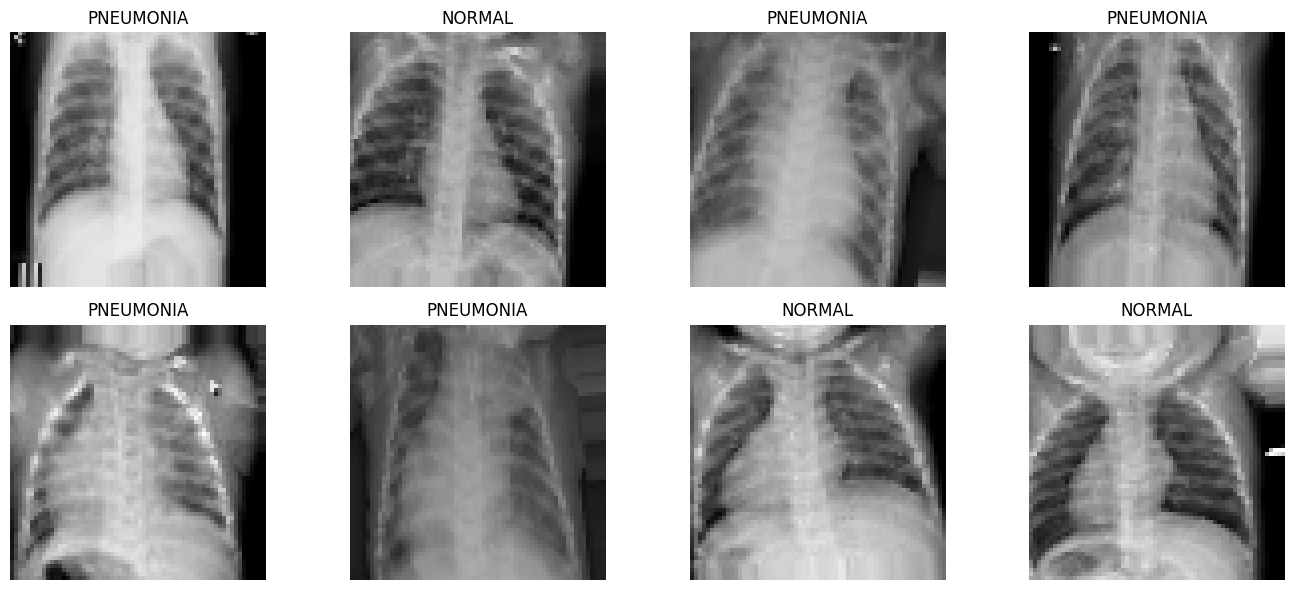

In [26]:
# Visualise a batch of training images
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flat, imgs, labels):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title('PNEUMONIA' if lbl == 1 else 'NORMAL')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [27]:
# TODO: implement compute_class_weights() in src/data_loader.py
class_weights = compute_class_weights(train_gen)
print('Class weights:', class_weights)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## 2. Build and Train the Baseline MLP

Implement `build_baseline_mlp()` in `src/models.py` before running the cells below.

In [28]:
from src.models import build_baseline_mlp

model = build_baseline_mlp(
    input_shape=(64, 64, 3),
    activation='relu',
    optimizer='adam',
    learning_rate=1e-3,
)
model.summary()

Model: "custom_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,321 (24.63 MB)

 Trainable params: 6,456,321 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6142 - loss: 1.2411
Epoch 1: val_loss improved from None to 0.57657, saving model to models/baseline_mlp_best.keras

Epoch 1: finished saving model to models/baseline_mlp_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 341ms/step - accuracy: 0.6921 - loss: 0.7516 - val_accuracy: 0.6875 - val_loss: 0.5766 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.7644 - loss: 0.4765
Epoch 2: val_loss did not improve from 0.57657
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 327ms/step - accuracy: 0.7851 - loss: 0.4549 - val_accuracy: 0.6875 - val_loss: 0.6376 - learning_rate: 9.9384e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.8034 - loss: 0.4191
Epoch 3: val_loss did not improve from 0.57657

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00048776413314044476.
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 334ms/step - accuracy: 0.8154 - loss: 0.4107 - val_accuracy: 0.6250 - val_los

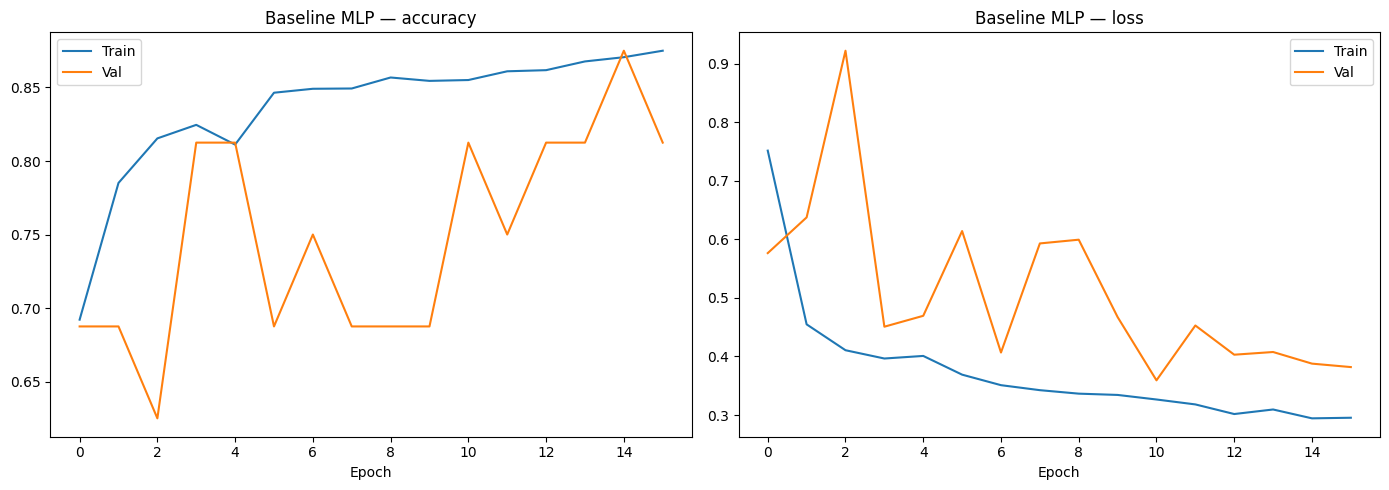

In [31]:
from src.train import get_callbacks, get_lr_schedule, train_model, plot_history

callbacks = get_callbacks(model_name='baseline_mlp', patience=5)
lr_cb = get_lr_schedule(schedule_type='cosine', initial_lr=1e-3, epochs=20)

history = train_model(
    model,
    train_gen,
    val_gen,
    epochs=20,
    class_weights=class_weights,
    callbacks=callbacks + [lr_cb],
)
plot_history(history, title='Baseline MLP')

## 3. Experiment: Activation Functions

Train three models with different activations and compare validation accuracy.

In [32]:
results = {}
for act in ['relu', 'leaky_relu', 'elu']:
    m = build_baseline_mlp(input_shape=(64, 64, 3), activation=act)
    h = train_model(m, train_gen, val_gen, epochs=10, class_weights=class_weights)
    results[act] = max(h.history['val_accuracy'])
    print(f'{act}: best val_accuracy = {results[act]:.4f}')

print('\nBest activation:', max(results, key=results.get))

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 321ms/step - accuracy: 0.6599 - loss: 0.7227 - val_accuracy: 0.6250 - val_loss: 0.6071
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 322ms/step - accuracy: 0.7753 - loss: 0.4666 - val_accuracy: 0.7500 - val_loss: 0.5888
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 320ms/step - accuracy: 0.8023 - loss: 0.4326 - val_accuracy: 0.6250 - val_loss: 0.6380
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 318ms/step - accuracy: 0.8079 - loss: 0.4225 - val_accuracy: 0.6250 - val_loss: 0.4937
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 324ms/step - accuracy: 0.8152 - loss: 0.4029 - val_accuracy: 0.5625 - val_loss: 0.8096
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 325ms/step - accuracy: 0.8349 - loss: 0.3709 - val_accuracy: 0.6250 - val_loss: 0.6877
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 328ms/step - accuracy: 0.8301 - loss: 0.3761 - val_accuracy: 0.8125 - val_loss: 0.4671
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 325ms/step - accuracy: 0.8365 - loss: 0

## 4. Experiment: Optimizers

Compare SGD, Adam, RMSprop, and Nadam.

In [33]:
opt_results = {}
for opt in ['sgd', 'adam', 'rmsprop', 'nadam']:
    m = build_baseline_mlp(input_shape=(64, 64, 3), optimizer=opt)
    h = train_model(m, train_gen, val_gen, epochs=10, class_weights=class_weights)
    opt_results[opt] = max(h.history['val_accuracy'])
    print(f'{opt}: best val_accuracy = {opt_results[opt]:.4f}')

print('\nBest optimizer:', max(opt_results, key=opt_results.get))

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 333ms/step - accuracy: 0.6361 - loss: 0.6519 - val_accuracy: 0.7500 - val_loss: 0.6250
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 330ms/step - accuracy: 0.7575 - loss: 0.5931 - val_accuracy: 0.5625 - val_loss: 0.5962
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.7859 - loss: 0.5475 - val_accuracy: 0.6250 - val_loss: 0.6035
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 328ms/step - accuracy: 0.8110 - loss: 0.5009 - val_accuracy: 0.7500 - val_loss: 0.5399
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 328ms/step - accuracy: 0.8171 - loss: 0.4671 - val_accuracy: 0.8125 - val_loss: 0.5101
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.8250 - loss: 0.4372 - val_accuracy: 0.6875 - val_loss: 0.5172
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 329ms/step - accuracy: 0.8278 - loss: 0.4176 - val_accuracy: 0.7500 - val_loss: 0.5008
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 327ms/step - accuracy: 0.8382 - loss: 0

## 5. Reflection Questions

Answer in the cells below (Markdown):

1. Why is class weighting necessary for this dataset?
2. How does the choice of activation function affect gradient flow?
3. What are the trade-offs between SGD and Adam?
4. What is the effect of learning-rate scheduling on training stability?

1. **Class weighting is necessary because the dataset is imbalanced**, containing significantly more **PNEUMONIA** images than **NORMAL** images. Without class weights, the model may become biased toward the majority class and predict pneumonia more frequently, leading to poor classification of normal cases. By applying class weights, the loss function penalizes mistakes on minority classes more heavily, helping the model learn balanced decision boundaries and improving generalization performance.

2. **Activation functions affect how gradients propagate through the network during backpropagation.** ReLU helps reduce vanishing gradients and is computationally efficient, but it can suffer from the *dying ReLU problem* where neurons stop updating for negative inputs. LeakyReLU allows small negative gradients, preventing inactive neurons, while ELU produces smooth negative outputs that improve gradient flow and training stability. In the experiments, **ReLU achieved the highest validation accuracy (93.75%)**, followed by **LeakyReLU (87.50%)** and **ELU (81.25%)**.

3. **SGD is simple, memory-efficient, and often provides better long-term generalization**, but it converges slowly and requires careful learning-rate tuning. Adam uses adaptive learning rates, converges faster, and is easier to optimize for deep networks, but it may sometimes overfit or converge to suboptimal minima. In the experiments, **Nadam achieved the best validation accuracy (87.50%)**, while **SGD** and **Adam** achieved **81.25%**, and **RMSprop** performed worst (**50.00%**).

4. **Learning-rate scheduling improves training stability** by adjusting the learning rate during training instead of keeping it constant. Higher learning rates in early epochs help the model learn quickly, while gradually reducing the learning rate later allows finer updates and smoother convergence. This reduces oscillations, prevents overshooting minima, improves validation performance, and helps stabilize training. In this project, **cosine learning-rate scheduling** improved convergence and training stability during later epochs.